In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# 1. Carregar os dados
df = pd.read_csv("../data/train.csv", parse_dates=["date"])

In [20]:
# --- Pergunta 1: estrutura básica ---
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(913000, 4)
date     datetime64[us]
store             int64
item              int64
sales             int64
dtype: object
date     0
store    0
item     0
sales    0
dtype: int64


In [24]:
# --- Pergunta 2: cobertura temporal ---
print(df["date"].min())
print(df["date"].max())
print(df["item"].nunique())
print(df["store"].nunique())

2013-01-01 00:00:00
2017-12-31 00:00:00
50
10


In [25]:
# --- Pergunta 3: distribuição da variável alvo ---
print(df["sales"].describe())
print(df[df['sales'] < 0])

count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64
Empty DataFrame
Columns: [date, store, item, sales]
Index: []


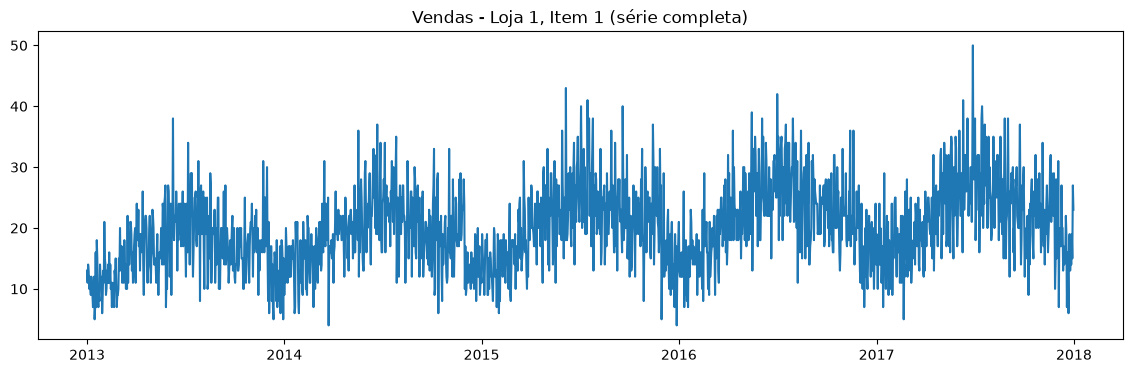

In [27]:
# --- Pergunta 4: padrão temporal ---
sample = df[(df["store"] == 1) & (df["item"] == 1)].sort_values("date")

plt.figure(figsize=(14, 4))
plt.plot(sample["date"], sample["sales"])
plt.title("Vendas - Loja 1, Item 1 (série completa)")
plt.show()

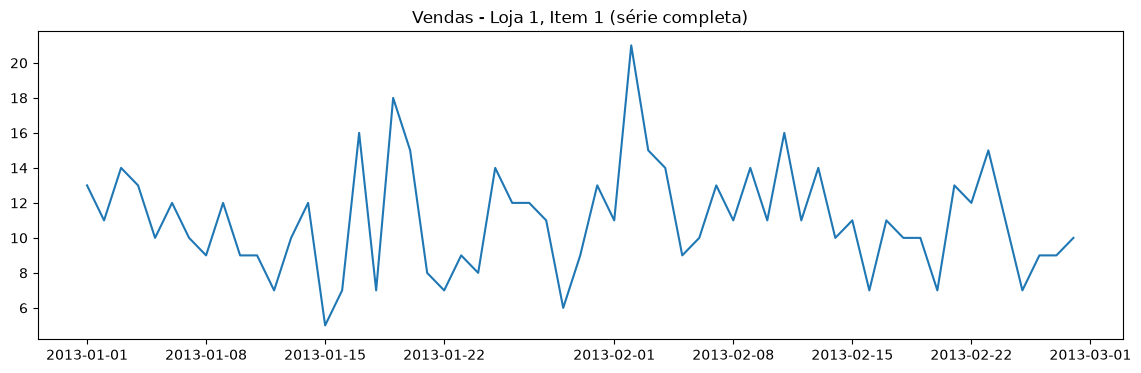

In [30]:
# Padrão semanal
zoom = sample[sample["date"] < "2013-03-01"]

plt.figure(figsize=(14, 4))
plt.plot(zoom["date"], zoom["sales"])
plt.title("Vendas - Loja 1, Item 1 (série completa)")
plt.show()

In [31]:
# --- Pergunta 5: comparação entre lojas ---
vendas_por_loja = df.groupby("store")["sales"].mean()
print(vendas_por_loja.sort_values(ascending=False))

store
2     67.033165
8     64.142048
3     59.530602
10    58.709288
9     55.049025
4     54.902946
1     47.268379
5     39.770164
6     39.733516
7     36.363735
Name: sales, dtype: float64


In [32]:
# --- Confirmar a tendência de crescimento ano a ano ---
df["year"] = df["date"].dt.year
vendas_por_ano = df.groupby("year")["sales"].mean()
print(vendas_por_ano)


# --- Confirmar o padrão semanal exato ---
df["day_of_week"] = df["date"].dt.dayofweek  # 0=segunda, 6=domingo
vendas_por_dia_semana = df.groupby("day_of_week")["sales"].mean()
print(vendas_por_dia_semana)

year
2013    43.513660
2014    50.057436
2015    52.256915
2016    56.596503
2017    58.815014
Name: sales, dtype: float64
day_of_week
0    41.429638
1    48.225908
2    48.368506
3    51.723218
4    55.157249
5    58.662697
6    62.143333
Name: sales, dtype: float64
